## Ejercicio 1: Evaluación de solicitud de crédito bancario

### Ficha PEAS

| Elemento | Descripción |
|---|---|
| **Percepción (S)** | Ingreso mensual del solicitante, monto solicitado, historial de morosidad |
| **Acciones (A)** | Aprobar / Aprobar con condiciones / Rechazar la solicitud |
| **Entorno (E)** | Sistema de evaluación crediticia bancaria, con solicitudes que llegan una por una |
| **Objetivo** | Aprobar créditos que el solicitante pueda pagar, minimizando el riesgo de impago para el banco |
| **Medida de desempeño (P)** | Tasa de créditos aprobados correctamente pagados, tasa de créditos rechazados que sí eran viables (oportunidad perdida) |

### Justificación de las reglas

Las reglas se basan en la relación monto/ingreso porque refleja qué tan comprometido quedaría el ingreso mensual del solicitante con la deuda. Una relación baja indica que el crédito es fácilmente pagable; una relación alta indica mayor riesgo de impago, incluso sin historial moroso. El historial de morosidad actúa como agravante: ante la misma relación monto/ingreso, un solicitante con historial moroso representa mayor riesgo que uno sin historial, por lo que se le exige una relación más baja para ser aprobado sin condiciones.
    

### Código

In [1]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    # Relacion entre lo solicitado y la capacidad de pago mensual
    relacion = monto_solicitado / ingreso_mensual

    if relacion <= 0.3 and not tiene_historial_moroso:
        return "aprobar", "relacion monto/ingreso baja (<=0.3) y sin historial moroso"
    elif relacion <= 0.3 and tiene_historial_moroso:
        return "aprobar con condiciones", "relacion monto/ingreso baja pero con historial moroso"
    elif relacion <= 0.5 and not tiene_historial_moroso:
        return "aprobar con condiciones", "relacion monto/ingreso moderada (0.3-0.5) sin historial moroso"
    elif relacion <= 0.5 and tiene_historial_moroso:
        return "rechazar", "relacion monto/ingreso moderada con historial moroso"
    else:
        return "rechazar", "relacion monto/ingreso mayor a 0.5"

### Simulación y pruebas

In [4]:
casos = [
    (5000, 1000, False),   # relacion 0.2 - baja, sin mora
    (3000, 900, True),     # relacion 0.3 - caso limite, con mora
    (4000, 1600, False),   # relacion 0.4 - moderada, sin mora
    (2500, 1250, True),    # relacion 0.5 - caso limite, con mora
    (6000, 4000, False),   # relacion 0.67 - alta, sin mora
    (3500, 3000, True),    # relacion 0.86 - alta, con mora
]

for ingreso, monto, moroso in casos:
    accion, motivo = agente_credito(ingreso, monto, moroso)
    print(f"Ingreso: S/{ingreso} | Monto: S/{monto} | Moroso: {moroso} -> {accion} ({motivo})")

Ingreso: S/5000 | Monto: S/1000 | Moroso: False -> aprobar (relacion monto/ingreso baja (<=0.3) y sin historial moroso)
Ingreso: S/3000 | Monto: S/900 | Moroso: True -> aprobar con condiciones (relacion monto/ingreso baja pero con historial moroso)
Ingreso: S/4000 | Monto: S/1600 | Moroso: False -> aprobar con condiciones (relacion monto/ingreso moderada (0.3-0.5) sin historial moroso)
Ingreso: S/2500 | Monto: S/1250 | Moroso: True -> rechazar (relacion monto/ingreso moderada con historial moroso)
Ingreso: S/6000 | Monto: S/4000 | Moroso: False -> rechazar (relacion monto/ingreso mayor a 0.5)
Ingreso: S/3500 | Monto: S/3000 | Moroso: True -> rechazar (relacion monto/ingreso mayor a 0.5)


### Visualización

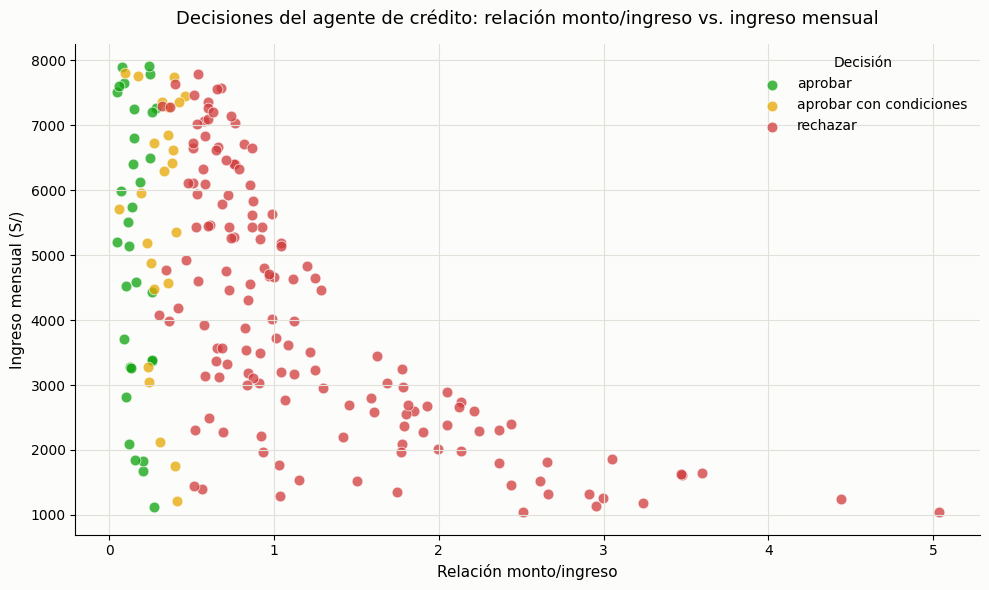

Total solicitudes: 200
aprobar: 32
aprobar con condiciones: 24
rechazar: 144


In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200
ingresos = np.random.uniform(1000, 8000, n)
montos = np.random.uniform(200, 6000, n)
morosos = np.random.rand(n) < 0.3  # 30% con historial moroso

resultados = [agente_credito(i, m, mo) for i, m, mo in zip(ingresos, montos, morosos)]
acciones = [r[0] for r in resultados]
relaciones = montos / ingresos

colores = {"aprobar": "#0ca30c", "aprobar con condiciones": "#e6a700", "rechazar": "#d03b3b"}

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
for accion in colores:
    mask = [a == accion for a in acciones]
    ax.scatter(
        relaciones[mask], ingresos[mask],
        s=60, alpha=0.75,
        c=colores[accion],
        edgecolors="white", linewidths=0.6,
        label=accion,
    )
ax.set_title("Decisiones del agente de crédito: relación monto/ingreso vs. ingreso mensual", fontsize=13, pad=14)
ax.set_xlabel("Relación monto/ingreso", fontsize=11)
ax.set_ylabel("Ingreso mensual (S/)", fontsize=11)
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Decisión", frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

print("Total solicitudes:", n)
for accion in colores:
    print(f"{accion}: {acciones.count(accion)}")